In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Contoh dataset kecil dengan 1 outlier
data_kecil = {'total_harga_transaksi': np.random.uniform(100_000, 500_000, 7).tolist() + [500_000_000]}
df_kecil   = pd.DataFrame(data_kecil).astype(int)

# Menghitung Z-score pada dataset kecil
mean_kecil                 = df_kecil['total_harga_transaksi'].mean()
std_kecil                  = df_kecil['total_harga_transaksi'].std()
df_kecil['zscore_harga']   = (df_kecil['total_harga_transaksi'] - mean_kecil) / std_kecil
df_kecil['zscore_outlier'] = (df_kecil['zscore_harga'] > 3) | (df_kecil['zscore_harga'] < -3)

df_kecil



,total_harga_transaksi,zscore_harga,zscore_outlier
0,249816,-0.353684,False
1,480285,-0.352380,False
2,392797,-0.352875,False
3,339463,-0.353177,False
4,162407,-0.354179,False
5,162397,-0.354179,False
6,123233,-0.354400,False
7,500000000,2.474873,False


In [ ]:
np.random.seed(42)

# Contoh dataset besar dengan 1 outlier
data_besar = {'total_harga_transaksi': np.random.uniform(100_000, 500_000, 100).tolist() + [500_000_000]}
df_besar   = pd.DataFrame(data_besar).astype(int)

# Menghitung Z-score pada dataset besar
mean_besar                 = df_besar['total_harga_transaksi'].mean()
std_besar                  = df_besar['total_harga_transaksi'].std()
df_besar['zscore_harga']   = (df_besar['total_harga_transaksi'] - mean_besar) / std_besar
df_besar['zscore_outlier'] = (df_besar['zscore_harga'] > 3) | (df_besar['zscore_harga'] < -3)

df_besar



,total_harga_transaksi,zscore_harga,zscore_outlier
0,249816,-0.100273,False
1,480285,-0.095638,False
2,392797,-0.097397,False
3,339463,-0.098470,False
4,162407,-0.102031,False
...,...,...,...
96,309093,-0.099081,False
97,271016,-0.099846,False
98,110167,-0.103081,False
99,143156,-0.102418,False


In [ ]:
# Menghitung Q1, Q3, dan IQR pada dataset kecil
Q1_kecil  = df_kecil['total_harga_transaksi'].quantile(0.25)
Q3_kecil  = df_kecil['total_harga_transaksi'].quantile(0.75)
IQR_kecil = Q3_kecil - Q1_kecil

# Menentukan batas atas dan bawah
lower_bound_kecil = Q1_kecil - 1.5 * IQR_kecil
upper_bound_kecil = Q3_kecil + 1.5 * IQR_kecil

print(f"Batas Bawah (IQR) pada dataset kecil: {lower_bound_kecil}")
print(f"Batas Atas (IQR) pada dataset kecil: {upper_bound_kecil}")

df_kecil['lower_bound'] = lower_bound_kecil
df_kecil['upper_bound'] = upper_bound_kecil
df_kecil['iqr_outlier'] = (df_kecil['total_harga_transaksi'] < lower_bound_kecil) | (df_kecil['total_harga_transaksi'] > upper_bound_kecil)

df_kecil



Batas Bawah (IQR) pada dataset kecil: -215992.25
Batas Atas (IQR) pada dataset kecil: 793065.75


,total_harga_transaksi,zscore_harga,zscore_outlier,lower_bound,upper_bound,iqr_outlier
0,249816,-0.353684,False,-215992.25,793065.75,False
1,480285,-0.352380,False,-215992.25,793065.75,False
2,392797,-0.352875,False,-215992.25,793065.75,False
3,339463,-0.353177,False,-215992.25,793065.75,False
4,162407,-0.354179,False,-215992.25,793065.75,False
5,162397,-0.354179,False,-215992.25,793065.75,False
6,123233,-0.354400,False,-215992.25,793065.75,False
7,500000000,2.474873,False,-215992.25,793065.75,True


In [ ]:
df_dropped = df_kecil.copy()
df_dropped = df_dropped[
   (df_dropped['total_harga_transaksi'] >= lower_bound_kecil) &
   (df_dropped['total_harga_transaksi'] <= upper_bound_kecil)
]

df_dropped


,total_harga_transaksi,zscore_harga,zscore_outlier,lower_bound,upper_bound,iqr_outlier
0,249816,-0.353684,False,-215992.25,793065.75,False
1,480285,-0.352380,False,-215992.25,793065.75,False
2,392797,-0.352875,False,-215992.25,793065.75,False
3,339463,-0.353177,False,-215992.25,793065.75,False
4,162407,-0.354179,False,-215992.25,793065.75,False
5,162397,-0.354179,False,-215992.25,793065.75,False
6,123233,-0.354400,False,-215992.25,793065.75,False


In [ ]:
df_winsorized = df_kecil.copy()
df_winsorized['total_harga_transaksi_winsorized'] = df_kecil['total_harga_transaksi'].clip(
   lower = lower_bound_kecil,
   upper = upper_bound_kecil
)

df_winsorized



,total_harga_transaksi,zscore_harga,zscore_outlier,lower_bound,upper_bound,iqr_outlier,total_harga_transaksi_winsorized
0,249816,-0.353684,False,-215992.25,793065.75,False,249816.00
1,480285,-0.352380,False,-215992.25,793065.75,False,480285.00
2,392797,-0.352875,False,-215992.25,793065.75,False,392797.00
3,339463,-0.353177,False,-215992.25,793065.75,False,339463.00
4,162407,-0.354179,False,-215992.25,793065.75,False,162407.00
5,162397,-0.354179,False,-215992.25,793065.75,False,162397.00
6,123233,-0.354400,False,-215992.25,793065.75,False,123233.00
7,500000000,2.474873,False,-215992.25,793065.75,True,793065.75


In [ ]:
df_transformed = df_kecil.copy()
df_transformed['total_harga_transaksi_log'] = np.log(df_transformed['total_harga_transaksi'])

df_transformed



,total_harga_transaksi,zscore_harga,zscore_outlier,lower_bound,upper_bound,iqr_outlier,total_harga_transaksi_log
0,249816,-0.353684,False,-215992.25,793065.75,False,12.428480
1,480285,-0.352380,False,-215992.25,793065.75,False,13.082135
2,392797,-0.352875,False,-215992.25,793065.75,False,12.881048
3,339463,-0.353177,False,-215992.25,793065.75,False,12.735120
4,162407,-0.354179,False,-215992.25,793065.75,False,11.997861
5,162397,-0.354179,False,-215992.25,793065.75,False,11.997799
6,123233,-0.354400,False,-215992.25,793065.75,False,11.721832
7,500000000,2.474873,False,-215992.25,793065.75,True,20.030119


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
df_ecommerce = pd.DataFrame({
   'total_harga_transaksi': np.random.lognormal(mean=12, sigma=0.1, size=1000)
}).astype(int)

df_ecommerce



,total_harga_transaksi
0,171043
1,160519
2,173645
3,189530
4,158988
...,...
995,158243
996,194807
997,173526
998,153719


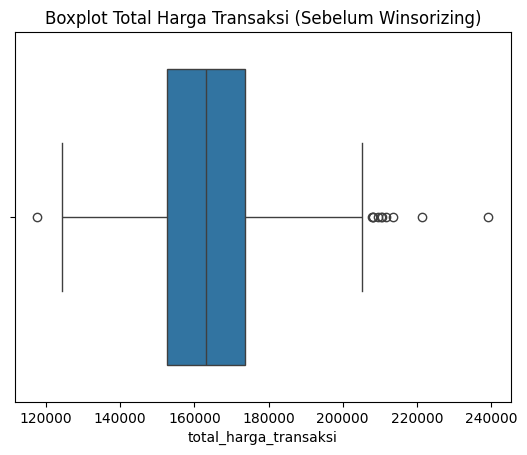

In [ ]:
sns.boxplot(x=df_ecommerce['total_harga_transaksi'])
plt.title('Boxplot Total Harga Transaksi (Sebelum Winsorizing)')
plt.show()


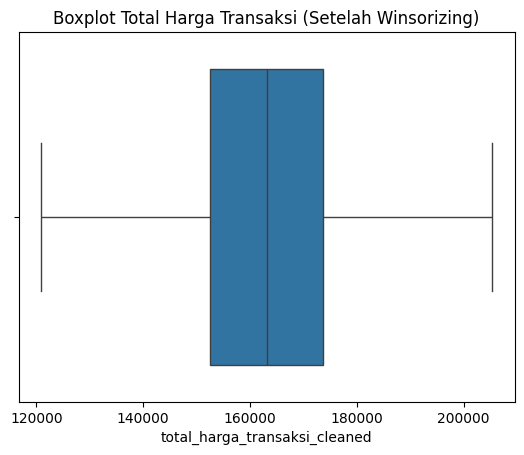

In [ ]:
Q1_harga = df_ecommerce['total_harga_transaksi'].quantile(0.25)
Q3_harga = df_ecommerce['total_harga_transaksi'].quantile(0.75)
IQR_harga = Q3_harga - Q1_harga

lower_bound_harga = Q1_harga - 1.5 * IQR_harga
upper_bound_harga = Q3_harga + 1.5 * IQR_harga

df_ecommerce['total_harga_transaksi_cleaned'] = df_ecommerce['total_harga_transaksi'].clip(
   lower=lower_bound_harga, upper=upper_bound_harga
)

# Visualisasi setelah winsorizing
sns.boxplot(x=df_ecommerce['total_harga_transaksi_cleaned'])
plt.title('Boxplot Total Harga Transaksi (Setelah Winsorizing)')
plt.show()


In [ ]:
df_ecommerce = pd.DataFrame({
   'rating_produk'   : [4, np.nan, 5, 3, np.nan, 4, 5, 4],
   'usia_konsumen'   : [25, 30, np.nan, 45, 22, 28, np.nan, 30],
   'jenis_pembayaran': ['Kartu Kredit', 'E-wallet', 'COD', 'Kartu Kredit', np.nan, 'E-wallet', 'E-wallet', np.nan],
})

# Imputasi dengan Mean untuk kolom numerik (rating_produk)
mean_rating = df_ecommerce['rating_produk'].mean()
df_ecommerce['rating_produk_filled'] = df_ecommerce['rating_produk'].fillna(mean_rating)

# Imputasi dengan Median untuk kolom numerik (usia_konsumen)
median_usia = df_ecommerce['usia_konsumen'].median()
df_ecommerce['usia_konsumen_filled'] = df_ecommerce['usia_konsumen'].fillna(median_usia)

# Imputasi dengan Mode untuk kolom kategorikal (jenis_pembayaran)
mode_pembayaran = df_ecommerce['jenis_pembayaran'].mode()[0]
df_ecommerce['jenis_pembayaran_filled'] = df_ecommerce['jenis_pembayaran'].fillna(mode_pembayaran)

df_ecommerce


,rating_produk,usia_konsumen,jenis_pembayaran,rating_produk_filled,usia_konsumen_filled,jenis_pembayaran_filled
0,4.0,25.0,Kartu Kredit,4.000000,25.0,Kartu Kredit
1,NaN,30.0,E-wallet,4.166667,30.0,E-wallet
2,5.0,NaN,COD,5.000000,29.0,COD
3,3.0,45.0,Kartu Kredit,3.000000,45.0,Kartu Kredit
4,NaN,22.0,NaN,4.166667,22.0,E-wallet
5,4.0,28.0,E-wallet,4.000000,28.0,E-wallet
6,5.0,NaN,E-wallet,5.000000,29.0,E-wallet
7,4.0,30.0,NaN,4.000000,30.0,E-wallet


In [ ]:
df_ts = pd.DataFrame({
   'tanggal_transaksi': pd.to_datetime(['2024-01-01', None, None, '2024-01-04', None, '2024-01-06']),
})

# Menggunakan ffill
df_ts['tanggal_transaksi_ffill'] = df_ts['tanggal_transaksi'].fillna(method='ffill')

# Menggunakan bfill
df_ts['tanggal_transaksi_bfill'] = df_ts['tanggal_transaksi'].fillna(method='bfill')

# Menggunakan interpolasi
df_ts['tanggal_transaksi_interpolated'] = df_ts['tanggal_transaksi'].interpolate()

df_ts


/tmp/ipython-input-2112080150.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ts['tanggal_transaksi_ffill'] = df_ts['tanggal_transaksi'].fillna(method='ffill')
/tmp/ipython-input-2112080150.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ts['tanggal_transaksi_bfill'] = df_ts['tanggal_transaksi'].fillna(method='bfill')


,tanggal_transaksi,tanggal_transaksi_ffill,tanggal_transaksi_bfill,tanggal_transaksi_interpolated
0,2024-01-01,2024-01-01,2024-01-01,2024-01-01
1,NaT,2024-01-01,2024-01-04,2024-01-02
2,NaT,2024-01-01,2024-01-04,2024-01-03
3,2024-01-04,2024-01-04,2024-01-04,2024-01-04
4,NaT,2024-01-04,2024-01-06,2024-01-05
5,2024-01-06,2024-01-06,2024-01-06,2024-01-06


In [ ]:
# Simulasi DataFrame studi kasus dengan missing values
data = {
   'tanggal_transaksi'     : ['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05'],
   'kategori_produk'       : ['Elektronik', 'Fashion', None, 'Buku', 'Elektronik'],
   'jenis_pembayaran'      : ['Kartu Kredit', 'E-wallet', 'COD', None, 'E-wallet'],
   'usia_konsumen'         : [25, None, 45, 22, None],
   'rating_produk'         : [4, 5, None, 3, 4],
   'durasi_pengiriman_hari': [2, None, 4, 5, 3]
}
df_ecommerce = pd.DataFrame(data)
df_ecommerce['tanggal_transaksi'] = pd.to_datetime(df_ecommerce['tanggal_transaksi'])

df_ecommerce


,tanggal_transaksi,kategori_produk,jenis_pembayaran,usia_konsumen,rating_produk,durasi_pengiriman_hari
0,2024-01-01,Elektronik,Kartu Kredit,25.0,4.0,2.0
1,2024-01-02,Fashion,E-wallet,NaN,5.0,NaN
2,2024-01-03,None,COD,45.0,NaN,4.0
3,2024-01-04,Buku,None,22.0,3.0,5.0
4,2024-01-05,Elektronik,E-wallet,NaN,4.0,3.0


In [ ]:
# 1. Imputasi Mode untuk data kategorikal
# Kolom 'kategori_produk' dan 'jenis_pembayaran' adalah kategorikal.
mode_kategori   = df_ecommerce['kategori_produk'].mode()[0]
mode_pembayaran = df_ecommerce['jenis_pembayaran'].mode()[0]
df_ecommerce['kategori_produk'].fillna(mode_kategori, inplace=True)
df_ecommerce['jenis_pembayaran'].fillna(mode_pembayaran, inplace=True)

df_ecommerce



/tmp/ipython-input-2189956781.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ecommerce['kategori_produk'].fillna(mode_kategori, inplace=True)
/tmp/ipython-input-2189956781.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

,tanggal_transaksi,kategori_produk,jenis_pembayaran,usia_konsumen,rating_produk,durasi_pengiriman_hari
0,2024-01-01,Elektronik,Kartu Kredit,25.0,4.0,2.0
1,2024-01-02,Fashion,E-wallet,NaN,5.0,NaN
2,2024-01-03,Elektronik,COD,45.0,NaN,4.0
3,2024-01-04,Buku,E-wallet,22.0,3.0,5.0
4,2024-01-05,Elektronik,E-wallet,NaN,4.0,3.0


In [ ]:
# 2. Imputasi Median untuk data numerik dengan potensi outlier/skew
# Kolom 'usia_konsumen' bisa memiliki outlier, sehingga median lebih aman.
median_usia = df_ecommerce['usia_konsumen'].median()
df_ecommerce['usia_konsumen'].fillna(median_usia, inplace=True)

df_ecommerce



/tmp/ipython-input-3301273846.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ecommerce['usia_konsumen'].fillna(median_usia, inplace=True)


,tanggal_transaksi,kategori_produk,jenis_pembayaran,usia_konsumen,rating_produk,durasi_pengiriman_hari
0,2024-01-01,Elektronik,Kartu Kredit,25.0,4.0,2.0
1,2024-01-02,Fashion,E-wallet,25.0,5.0,NaN
2,2024-01-03,Elektronik,COD,45.0,NaN,4.0
3,2024-01-04,Buku,E-wallet,22.0,3.0,5.0
4,2024-01-05,Elektronik,E-wallet,25.0,4.0,3.0


In [ ]:
# 3. Interpolasi untuk data time-series
# Kolom 'durasi_pengiriman_hari' adalah numerik dan terkait dengan waktu.
# Kita asumsikan ada tren, jadi interpolasi lebih baik dari ffill.
df_ecommerce['durasi_pengiriman_hari'].interpolate(inplace=True)

df_ecommerce



/tmp/ipython-input-235969721.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ecommerce['durasi_pengiriman_hari'].interpolate(inplace=True)


,tanggal_transaksi,kategori_produk,jenis_pembayaran,usia_konsumen,rating_produk,durasi_pengiriman_hari
0,2024-01-01,Elektronik,Kartu Kredit,25.0,4.0,2.0
1,2024-01-02,Fashion,E-wallet,25.0,5.0,3.0
2,2024-01-03,Elektronik,COD,45.0,NaN,4.0
3,2024-01-04,Buku,E-wallet,22.0,3.0,5.0
4,2024-01-05,Elektronik,E-wallet,25.0,4.0,3.0


In [ ]:
df_warna = pd.DataFrame({'warna': ['merah', 'biru', 'hijau', 'merah', 'hijau']})

# Label encoding menggunakan factorize
df_warna['warna_encoded'] = pd.factorize(df_warna['warna'])[0]
df_warna



,warna,warna_encoded
0,merah,0
1,biru,1
2,hijau,2
3,merah,0
4,hijau,2


In [ ]:
df_level = pd.DataFrame({'level': ['sedang', 'tinggi', 'sedang', 'rendah', 'rendah']})

# Mapping kategori ke urutan
ordinal_mapping = {'rendah': 1, 'sedang': 2, 'tinggi': 3}

df_level['level_encoded'] = df_level['level'].map(ordinal_mapping)
df_level



,level,level_encoded
0,sedang,2
1,tinggi,3
2,sedang,2
3,rendah,1
4,rendah,1


In [ ]:
df_warna = pd.DataFrame({'warna': ['merah', 'biru', 'hijau', 'merah', 'hijau']})

# One-hot encoding menggunakan pd.get_dummies
df_onehot = pd.get_dummies(df_warna, columns=['warna'])
df_onehot



,warna_biru,warna_hijau,warna_merah
0,False,False,True
1,True,False,False
2,False,True,False
3,False,False,True
4,False,True,False


In [ ]:
df_kategori = pd.DataFrame({'kategori': ['A', 'A', 'B', 'C', 'C', 'C', 'D', 'E']})

# Label encoding menggunakan factorize
df_kategori['kategori_encoded'] = pd.factorize(df_kategori['kategori'])[0]

# Mengubah angka menjadi biner dan membuat kolom biner
df_kategori[['bin_1', 'bin_2', 'bin_3']] = df_kategori['kategori_encoded'].apply(lambda x: list(f"{x:03b}")).apply(pd.Series)
df_kategori


,kategori,kategori_encoded,bin_1,bin_2,bin_3
0,A,0,0,0,0
1,A,0,0,0,0
2,B,1,0,0,1
3,C,2,0,1,0
4,C,2,0,1,0
5,C,2,0,1,0
6,D,3,0,1,1
7,E,4,1,0,0


In [ ]:
df_kategori = pd.DataFrame({'kategori': ['A', 'A', 'B', 'C', 'C', 'C', 'D', 'E']})

# Frequency encoding menggunakan value_counts
frequency_encoding = df_kategori['kategori'].value_counts()

df_kategori['kategori_encoded'] = df_kategori['kategori'].map(frequency_encoding)
df_kategori



,kategori,kategori_encoded
0,A,2
1,A,2
2,B,1
3,C,3
4,C,3
5,C,3
6,D,1
7,E,1


In [ ]:
df_ecommerce = pd.DataFrame({
   'kategori_produk' : ['Elektronik', 'Fashion', 'Fashion', 'Buku', 'Elektronik'],
   'jenis_pembayaran': ['Kartu Kredit', 'E-wallet', 'COD', 'Kartu Kredit', 'E-wallet'],
   'rating_produk'   : ['Buruk', 'Sangat Baik', 'Sedang', 'Baik', 'Sangat Baik'],
   'kota_pengiriman' : ['Jakarta', 'Surabaya', 'Bandung', 'Jakarta', 'Bandung']
})

df_ecommerce


,kategori_produk,jenis_pembayaran,rating_produk,kota_pengiriman
0,Elektronik,Kartu Kredit,Buruk,Jakarta
1,Fashion,E-wallet,Sangat Baik,Surabaya
2,Fashion,COD,Sedang,Bandung
3,Buku,Kartu Kredit,Baik,Jakarta
4,Elektronik,E-wallet,Sangat Baik,Bandung


In [ ]:
# 1. Ordinal Encoding untuk data Ordinal
# Kolom 'rating_produk' memiliki urutan: Buruk < Sedang < Baik < Sangat Baik.
# Kita buat kamus mapping manual.
rating_map = {'Buruk': 1, 'Sedang': 2, 'Baik': 3, 'Sangat Baik': 4}
df_ecommerce['rating_encoded'] = df_ecommerce['rating_produk'].map(rating_map)

df_ecommerce


,kategori_produk,jenis_pembayaran,rating_produk,kota_pengiriman,rating_encoded
0,Elektronik,Kartu Kredit,Buruk,Jakarta,1
1,Fashion,E-wallet,Sangat Baik,Surabaya,4
2,Fashion,COD,Sedang,Bandung,2
3,Buku,Kartu Kredit,Baik,Jakarta,3
4,Elektronik,E-wallet,Sangat Baik,Bandung,4


In [ ]:
# 2. One-Hot Encoding untuk data Nominal
# Kolom 'jenis_pembayaran' dan 'kategori_produk' tidak memiliki urutan, jadi One-Hot Encoding adalah pilihan terbaik.
# Pandas menyediakan fungsi get_dummies() yang sangat mudah digunakan.
df_encoded = pd.get_dummies(df_ecommerce, columns=['kategori_produk', 'jenis_pembayaran'], dtype=int)

df_encoded


,rating_produk,kota_pengiriman,rating_encoded,kategori_produk_Buku,kategori_produk_Elektronik,kategori_produk_Fashion,jenis_pembayaran_COD,jenis_pembayaran_E-wallet,jenis_pembayaran_Kartu Kredit
0,Buruk,Jakarta,1,0,1,0,0,0,1
1,Sangat Baik,Surabaya,4,0,0,1,0,1,0
2,Sedang,Bandung,2,0,0,1,1,0,0
3,Baik,Jakarta,3,1,0,0,0,0,1
4,Sangat Baik,Bandung,4,0,1,0,0,1,0


In [ ]:
# 3. Penanganan High-Cardinality
# Kolom 'kota_pengiriman' bisa memiliki banyak nilai unik.
# Kita bisa menggunakan binary encoding agar lebih efisien.

# Label encoding pada kolom 'kota_pengiriman'
df_ecommerce['kota_pengiriman_encoded'] = pd.factorize(df_ecommerce['kota_pengiriman'])[0]

# Hitung jumlah bit yang dibutuhkan
digit = np.log2(df_ecommerce['kota_pengiriman_encoded'].max() + 1)
digit = int(np.ceil(digit))

# Mengubah angka menjadi biner dan membuat kolom biner
df_ecommerce[[f'kp_{i+1}' for i in range(digit)]] = df_ecommerce['kota_pengiriman_encoded'].apply(lambda x: list(f"{x:0{digit}b}")).apply(pd.Series)

df_ecommerce


,kategori_produk,jenis_pembayaran,rating_produk,kota_pengiriman,rating_encoded,kota_pengiriman_encoded,kp_1,kp_2
0,Elektronik,Kartu Kredit,Buruk,Jakarta,1,0,0,0
1,Fashion,E-wallet,Sangat Baik,Surabaya,4,1,0,1
2,Fashion,COD,Sedang,Bandung,2,2,1,0
3,Buku,Kartu Kredit,Baik,Jakarta,3,0,0,0
4,Elektronik,E-wallet,Sangat Baik,Bandung,4,2,1,0


In [ ]:
df_skala = pd.DataFrame({
   'harga_rumah': [100000000, 250000000, 500000000, 750000000],
   'luas_tanah' : [100, 200, 300, 400]
})

# Normalisasi (Min-Max Scaling) secara manual
min_harga = df_skala['harga_rumah'].min()
max_harga = df_skala['harga_rumah'].max()
df_skala['harga_rumah_minmax'] = (df_skala['harga_rumah'] - min_harga) / (max_harga - min_harga)

min_luas = df_skala['luas_tanah'].min()
max_luas = df_skala['luas_tanah'].max()
df_skala['luas_tanah_minmax'] = (df_skala['luas_tanah'] - min_luas) / (max_luas - min_luas)

df_skala


,harga_rumah,luas_tanah,harga_rumah_minmax,luas_tanah_minmax
0,100000000,100,0.000000,0.000000
1,250000000,200,0.230769,0.333333
2,500000000,300,0.615385,0.666667
3,750000000,400,1.000000,1.000000


In [ ]:
# Standardisasi (StandardScaler) secara manual
mean_harga = df_skala['harga_rumah'].mean()
std_harga  = df_skala['harga_rumah'].std()
df_skala['harga_rumah_standard'] = (df_skala['harga_rumah'] - mean_harga) / std_harga

mean_luas = df_skala['luas_tanah'].mean()
std_luas  = df_skala['luas_tanah'].std()
df_skala['luas_tanah_standard'] = (df_skala['luas_tanah'] - mean_luas) / std_luas

df_skala


,harga_rumah,luas_tanah,harga_rumah_minmax,luas_tanah_minmax,harga_rumah_standard,luas_tanah_standard
0,100000000,100,0.000000,0.000000,-1.049781,-1.161895
1,250000000,200,0.230769,0.333333,-0.524891,-0.387298
2,500000000,300,0.615385,0.666667,0.349927,0.387298
3,750000000,400,1.000000,1.000000,1.224745,1.161895


In [ ]:
# Robust Scaler manual
median_harga = df_skala['harga_rumah'].median()
q1_harga     = df_skala['harga_rumah'].quantile(0.25)
q3_harga     = df_skala['harga_rumah'].quantile(0.75)
iqr_harga    = q3_harga - q1_harga
df_skala['harga_rumah_robust'] = (df_skala['harga_rumah'] - median_harga) / iqr_harga

median_luas = df_skala['luas_tanah'].median()
q1_luas     = df_skala['luas_tanah'].quantile(0.25)
q3_luas     = df_skala['luas_tanah'].quantile(0.75)
iqr_luas    = q3_luas - q1_luas
df_skala['luas_tanah_robust'] = (df_skala['luas_tanah'] - median_luas) / iqr_luas

df_skala


,harga_rumah,luas_tanah,harga_rumah_minmax,luas_tanah_minmax,harga_rumah_standard,luas_tanah_standard,harga_rumah_robust,luas_tanah_robust
0,100000000,100,0.000000,0.000000,-1.049781,-1.161895,-0.785714,-1.000000
1,250000000,200,0.230769,0.333333,-0.524891,-0.387298,-0.357143,-0.333333
2,500000000,300,0.615385,0.666667,0.349927,0.387298,0.357143,0.333333
3,750000000,400,1.000000,1.000000,1.224745,1.161895,1.071429,1.000000


In [ ]:
import pandas as pd
import numpy as np

# Simulasi DataFrame studi kasus dengan data bersih
df_ecommerce = pd.DataFrame({
   'total_harga_transaksi': np.random.lognormal(mean=12, sigma=0.8, size=20).astype(int),
   'usia_konsumen'        : np.random.randint(18, 60, size=20)
})

# Menambahkan outlier ekstrem untuk total_harga_transaksi
df_ecommerce.loc[19, 'total_harga_transaksi'] = 150000000

df_ecommerce



,total_harga_transaksi,usia_konsumen
0,498562,53
1,341023,25
2,170707,46
3,96998,49
4,284525,35
5,222969,23
6,333085,35
7,270529,36
8,376864,39
9,106065,54


In [ ]:
# 1. Min-Max Scaling
# Contoh pada 'usia_konsumen' karena distribusinya cenderung tidak memiliki outlier ekstrem
usia_konsumen_min = df_ecommerce['usia_konsumen'].min()
usia_konsumen_max = df_ecommerce['usia_konsumen'].max()

df_ecommerce['usia_konsumen_minmax'] = (df_ecommerce['usia_konsumen'] - usia_konsumen_min) / (usia_konsumen_max - usia_konsumen_min)

# Bandingkan jika diterapkan pada 'total_harga_transaksi'
total_harga_transaksi_min = df_ecommerce['total_harga_transaksi'].min()
total_harga_transaksi_max = df_ecommerce['total_harga_transaksi'].max()

df_ecommerce['total_harga_transaksi_minmax'] = (df_ecommerce['total_harga_transaksi'] - total_harga_transaksi_min) / (total_harga_transaksi_max - total_harga_transaksi_min)

df_ecommerce



,total_harga_transaksi,usia_konsumen,usia_konsumen_minmax,total_harga_transaksi_minmax
0,498562,53,0.868421,0.002700
1,341023,25,0.131579,0.001649
2,170707,46,0.684211,0.000513
3,96998,49,0.763158,0.000022
4,284525,35,0.394737,0.001272
5,222969,23,0.078947,0.000862
6,333085,35,0.394737,0.001596
7,270529,36,0.421053,0.001179
8,376864,39,0.500000,0.001888
9,106065,54,0.894737,0.000082


In [ ]:
# 1. Min-Max Scaling
# Contoh pada 'usia_konsumen' karena distribusinya cenderung tidak memiliki outlier ekstrem
usia_konsumen_min = df_ecommerce['usia_konsumen'].min()
usia_konsumen_max = df_ecommerce['usia_konsumen'].max()

df_ecommerce['usia_konsumen_minmax'] = (df_ecommerce['usia_konsumen'] - usia_konsumen_min) / (usia_konsumen_max - usia_konsumen_min)

# Bandingkan jika diterapkan pada 'total_harga_transaksi'
total_harga_transaksi_min = df_ecommerce['total_harga_transaksi'].min()
total_harga_transaksi_max = df_ecommerce['total_harga_transaksi'].max()

df_ecommerce['total_harga_transaksi_minmax'] = (df_ecommerce['total_harga_transaksi'] - total_harga_transaksi_min) / (total_harga_transaksi_max - total_harga_transaksi_min)

df_ecommerce



,total_harga_transaksi,usia_konsumen,usia_konsumen_minmax,total_harga_transaksi_minmax
0,498562,53,0.868421,0.002700
1,341023,25,0.131579,0.001649
2,170707,46,0.684211,0.000513
3,96998,49,0.763158,0.000022
4,284525,35,0.394737,0.001272
5,222969,23,0.078947,0.000862
6,333085,35,0.394737,0.001596
7,270529,36,0.421053,0.001179
8,376864,39,0.500000,0.001888
9,106065,54,0.894737,0.000082


In [ ]:
# 2. Robust Scaling
# Pilihan terbaik untuk 'total_harga_transaksi' karena memiliki outlier
q1_total_transaksi     = df_ecommerce['total_harga_transaksi'].quantile(0.25)
q3_total_transaksi     = df_ecommerce['total_harga_transaksi'].quantile(0.75)
iqr_total_transaksi    = q3_total_transaksi - q1_total_transaksi
median_total_transaksi = df_ecommerce['total_harga_transaksi'].median()

df_ecommerce['harga_robust_scaled'] = (df_ecommerce['total_harga_transaksi'] - median_total_transaksi) / iqr_total_transaksi

df_ecommerce



,total_harga_transaksi,usia_konsumen,usia_konsumen_minmax,total_harga_transaksi_minmax,harga_robust_scaled
0,498562,53,0.868421,0.002700,0.908155
1,341023,25,0.131579,0.001649,0.339996
2,170707,46,0.684211,0.000513,-0.274243
3,96998,49,0.763158,0.000022,-0.540072
4,284525,35,0.394737,0.001272,0.136238
5,222969,23,0.078947,0.000862,-0.085762
6,333085,35,0.394737,0.001596,0.311368
7,270529,36,0.421053,0.001179,0.085762
8,376864,39,0.500000,0.001888,0.469255
9,106065,54,0.894737,0.000082,-0.507372


Text(0.5, 1.0, 'Setelah Log Transform')

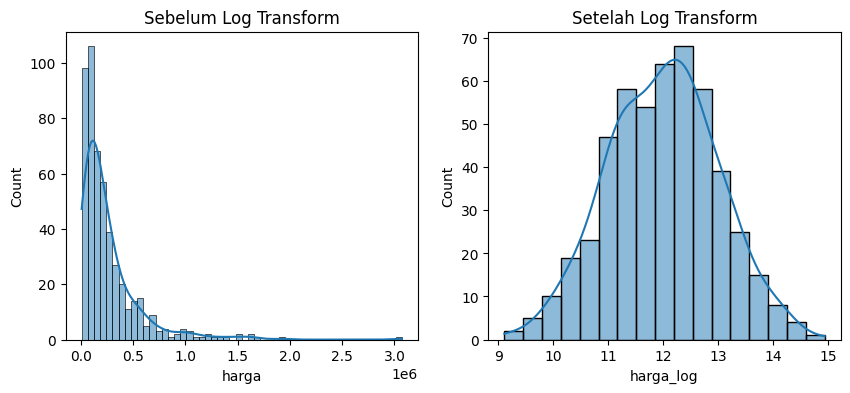

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Contoh data skewed
data = np.random.lognormal(mean=12, sigma=1, size=500)
df   = pd.DataFrame({'harga': data})

# Visualisasi sebelum dan sesudah Log Transformation
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['harga'], kde=True)
plt.title('Sebelum Log Transform')

df['harga_log'] = np.log1p(df['harga']) # np.log1p() handles values near zero

plt.subplot(1, 2, 2)
sns.histplot(df['harga_log'], kde=True)
plt.title('Setelah Log Transform')


Text(0.5, 1.0, 'Setelah Box-Cox Transform')

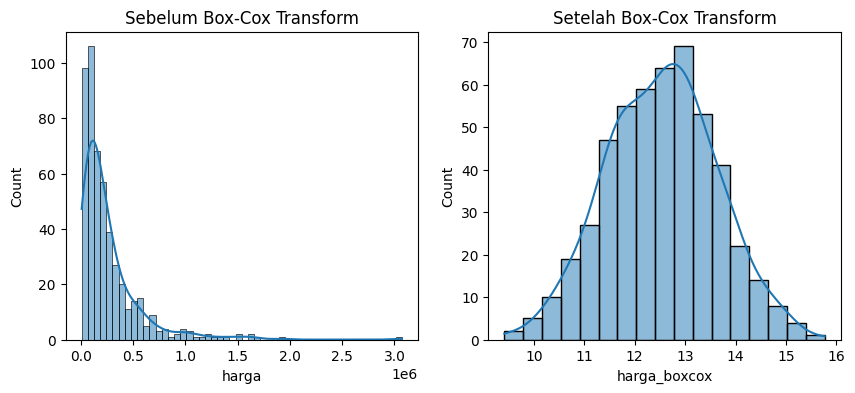

In [ ]:
from scipy import stats

# Visualisasi sebelum dan sesudah Box-Cox Transformation
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['harga'], kde=True)
plt.title('Sebelum Box-Cox Transform')

df['harga_boxcox'], _ = stats.boxcox(df['harga'])

plt.subplot(1, 2, 2)
sns.histplot(df['harga_boxcox'], kde=True)
plt.title('Setelah Box-Cox Transform')


Text(0.5, 1.0, 'Setelah Yeo-Johnson Transform')

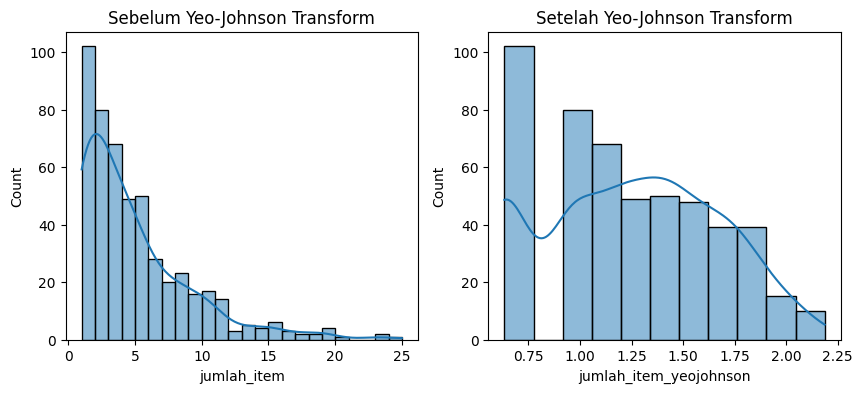

In [ ]:
# Contoh data dengan nilai nol
data_with_zero = np.random.geometric(p=0.2, size=500)
df_zero = pd.DataFrame({'jumlah_item': data_with_zero})

# Visualisasi sebelum dan sesudah Yeo-Johnson Transformation
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_zero['jumlah_item'], kde=True)
plt.title('Sebelum Yeo-Johnson Transform')

df_zero['jumlah_item_yeojohnson'], _ = stats.yeojohnson(df_zero['jumlah_item'])

plt.subplot(1, 2, 2)
sns.histplot(df_zero['jumlah_item_yeojohnson'], kde=True)
plt.title('Setelah Yeo-Johnson Transform')


/tmp/ipython-input-3069770529.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ecommerce['jumlah_item_terjual'].replace(0.0, 0.1, inplace=True) # menghindari masalah log(0)


Nilai Skewness sebelum transformasi:
Harga: 9.54
Jumlah Item: 1.76


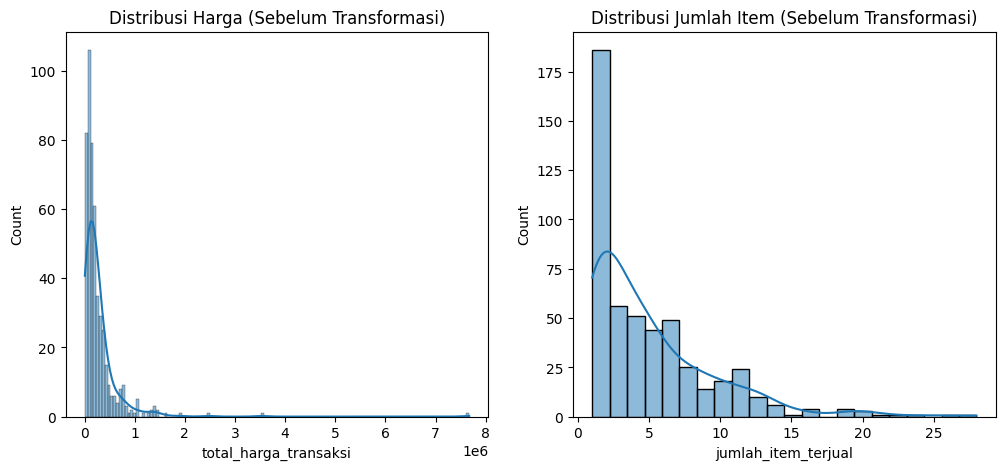

In [ ]:
#Contoh DataFrame studi kasus
np.random.seed(42)
df_ecommerce = pd.DataFrame({
   'total_harga_transaksi': np.random.lognormal(mean=12, sigma=1, size=500),
   'jumlah_item_terjual'  : np.random.geometric(p=0.2, size=500).astype(float)
})
df_ecommerce['jumlah_item_terjual'].replace(0.0, 0.1, inplace=True) # menghindari masalah log(0)
# Note: boxcox tidak bisa menangani nilai 0, yeojohnson bisa.

# Visualisasi distribusi awal
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_ecommerce['total_harga_transaksi'], kde=True)
plt.title('Distribusi Harga (Sebelum Transformasi)')
plt.subplot(1, 2, 2)
sns.histplot(df_ecommerce['jumlah_item_terjual'], kde=True)
plt.title('Distribusi Jumlah Item (Sebelum Transformasi)')

print("Nilai Skewness sebelum transformasi:")
print(f"Harga: {df_ecommerce['total_harga_transaksi'].skew():.2f}")
print(f"Jumlah Item: {df_ecommerce['jumlah_item_terjual'].skew():.2f}")


Nilai Skewness setelah transformasi:
Harga (Log): 0.18
Jumlah Item (Yeo-Johnson): 0.06


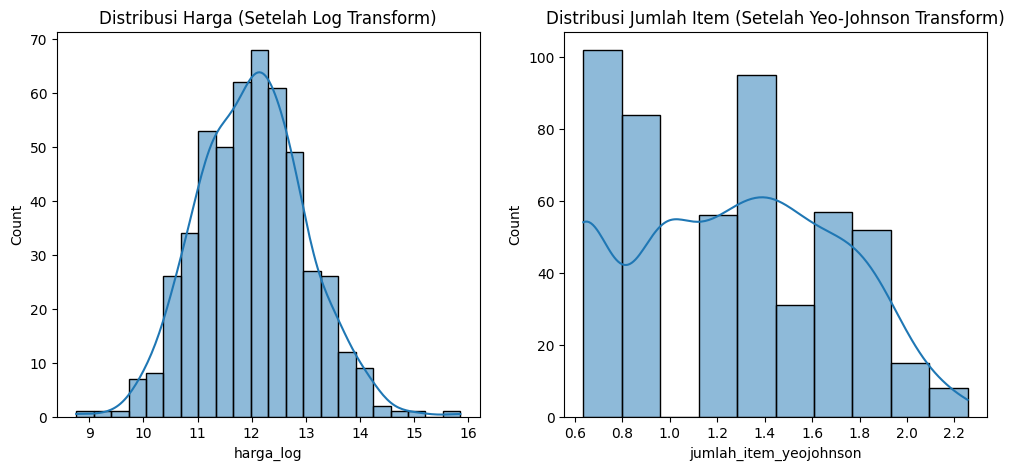

In [ ]:
# Transformasi Log pada 'total_harga_transaksi'
df_ecommerce['harga_log'] = np.log1p(df_ecommerce['total_harga_transaksi'])

# Transformasi Yeo-Johnson pada 'jumlah_item_terjual'
# Dipilih karena dapat menangani data dengan nilai nol
df_ecommerce['jumlah_item_yeojohnson'], _ = stats.yeojohnson(df_ecommerce['jumlah_item_terjual'])

# Visualisasi distribusi setelah transformasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_ecommerce['harga_log'], kde=True)
plt.title('Distribusi Harga (Setelah Log Transform)')
plt.subplot(1, 2, 2)
sns.histplot(df_ecommerce['jumlah_item_yeojohnson'], kde=True)
plt.title('Distribusi Jumlah Item (Setelah Yeo-Johnson Transform)')

print("Nilai Skewness setelah transformasi:")
print(f"Harga (Log): {df_ecommerce['harga_log'].skew():.2f}")
print(f"Jumlah Item (Yeo-Johnson): {df_ecommerce['jumlah_item_yeojohnson'].skew():.2f}")


In [ ]:
data = {
   'jenis_pembayaran'     : ['Kartu Kredit'] * 80 + ['E-wallet'] * 15 + ['COD'] * 5,
   'jumlah_item_terjual'  : np.random.randint(1, 10, 100),
   'total_harga_transaksi': np.random.lognormal(mean=12, sigma=0.8, size=100)
}
df = pd.DataFrame(data)

print("Distribusi Awal:")
print(df['jenis_pembayaran'].value_counts())

# Undersampling: Ambil jumlah sampel dari kelas mayoritas sesuai jumlah kelas minoritas
min_count = df['jenis_pembayaran'].value_counts().min()

df_minority    = df[df['jenis_pembayaran'] == 'COD']
df_majority_kk = df[df['jenis_pembayaran'] == 'Kartu Kredit'].sample(min_count, random_state=42)
df_majority_ew = df[df['jenis_pembayaran'] == 'E-wallet'].sample(min_count, random_state=42)

# Gabungkan DataFrame yang sudah di-undersample
df_undersampled = pd.concat([df_minority, df_majority_kk, df_majority_ew])

print("\nDistribusi Setelah Undersampling:")
print(df_undersampled['jenis_pembayaran'].value_counts())


Distribusi Awal:
jenis_pembayaran
Kartu Kredit    80
E-wallet        15
COD              5
Name: count, dtype: int64

Distribusi Setelah Undersampling:
jenis_pembayaran
COD             5
Kartu Kredit    5
E-wallet        5
Name: count, dtype: int64


In [ ]:
data = {
   'jenis_pembayaran'     : ['Kartu Kredit'] * 80 + ['E-wallet'] * 15 + ['COD'] * 5,
   'jumlah_item_terjual'  : np.random.randint(1, 10, 100),
   'total_harga_transaksi': np.random.lognormal(mean=12, sigma=0.8, size=100)
}
df = pd.DataFrame(data)

print("Distribusi Awal:")
print(df['jenis_pembayaran'].value_counts())

# Oversampling: Tentukan jumlah sampel baru sesuai kelas mayoritas
max_count = df['jenis_pembayaran'].value_counts().max()

df_minority_cod = df[df['jenis_pembayaran'] == 'COD']
df_minority_ew  = df[df['jenis_pembayaran'] == 'E-wallet']
df_majority     = df[df['jenis_pembayaran'] == 'Kartu Kredit']

# Oversample kelas minoritas hingga mencapai jumlah kelas mayoritas
df_cod_oversampled = df_minority_cod.sample(max_count, replace=True, random_state=42)
df_ew_oversampled  = df_minority_ew.sample(max_count, replace=True, random_state=42)

# Gabungkan DataFrame
df_oversampled = pd.concat([df_majority, df_cod_oversampled, df_ew_oversampled])

print("\nDistribusi Setelah Oversampling:")
print(df_oversampled['jenis_pembayaran'].value_counts())


Distribusi Awal:
jenis_pembayaran
Kartu Kredit    80
E-wallet        15
COD              5
Name: count, dtype: int64

Distribusi Setelah Oversampling:
jenis_pembayaran
Kartu Kredit    80
COD             80
E-wallet        80
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE

data = {
   'jenis_pembayaran'     : ['Kartu Kredit'] * 80 + ['E-wallet'] * 15 + ['COD'] * 5,
   'jumlah_item_terjual'  : np.random.randint(1, 10, 100),
   'total_harga_transaksi': np.random.lognormal(mean=12, sigma=0.8, size=100)
}
df = pd.DataFrame(data)

# Ubah data kategorikal menjadi numerik menggunakan factorize()
# Ini adalah langkah yang diperlukan sebelum menerapkan SMOTE
df['jenis_pembayaran_encoded'], unique_labels = pd.factorize(df['jenis_pembayaran'])

# Memisahkan fitur (X) dan target (y)
X = df[['jumlah_item_terjual', 'total_harga_transaksi']]
y = df['jenis_pembayaran_encoded']

print("Jumlah sampel sebelum SMOTE:")
print(y.value_counts())

# Terapkan SMOTE
smote = SMOTE(random_state=42, k_neighbors=4)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nJumlah sampel setelah SMOTE:")
print(y_resampled.value_counts())


Jumlah sampel sebelum SMOTE:
jenis_pembayaran_encoded
0    80
1    15
2     5
Name: count, dtype: int64

Jumlah sampel setelah SMOTE:
jenis_pembayaran_encoded
0    80
1    80
2    80
Name: count, dtype: int64
